In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
#creating database connection
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql('''select * from vendor_sales_summary''',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


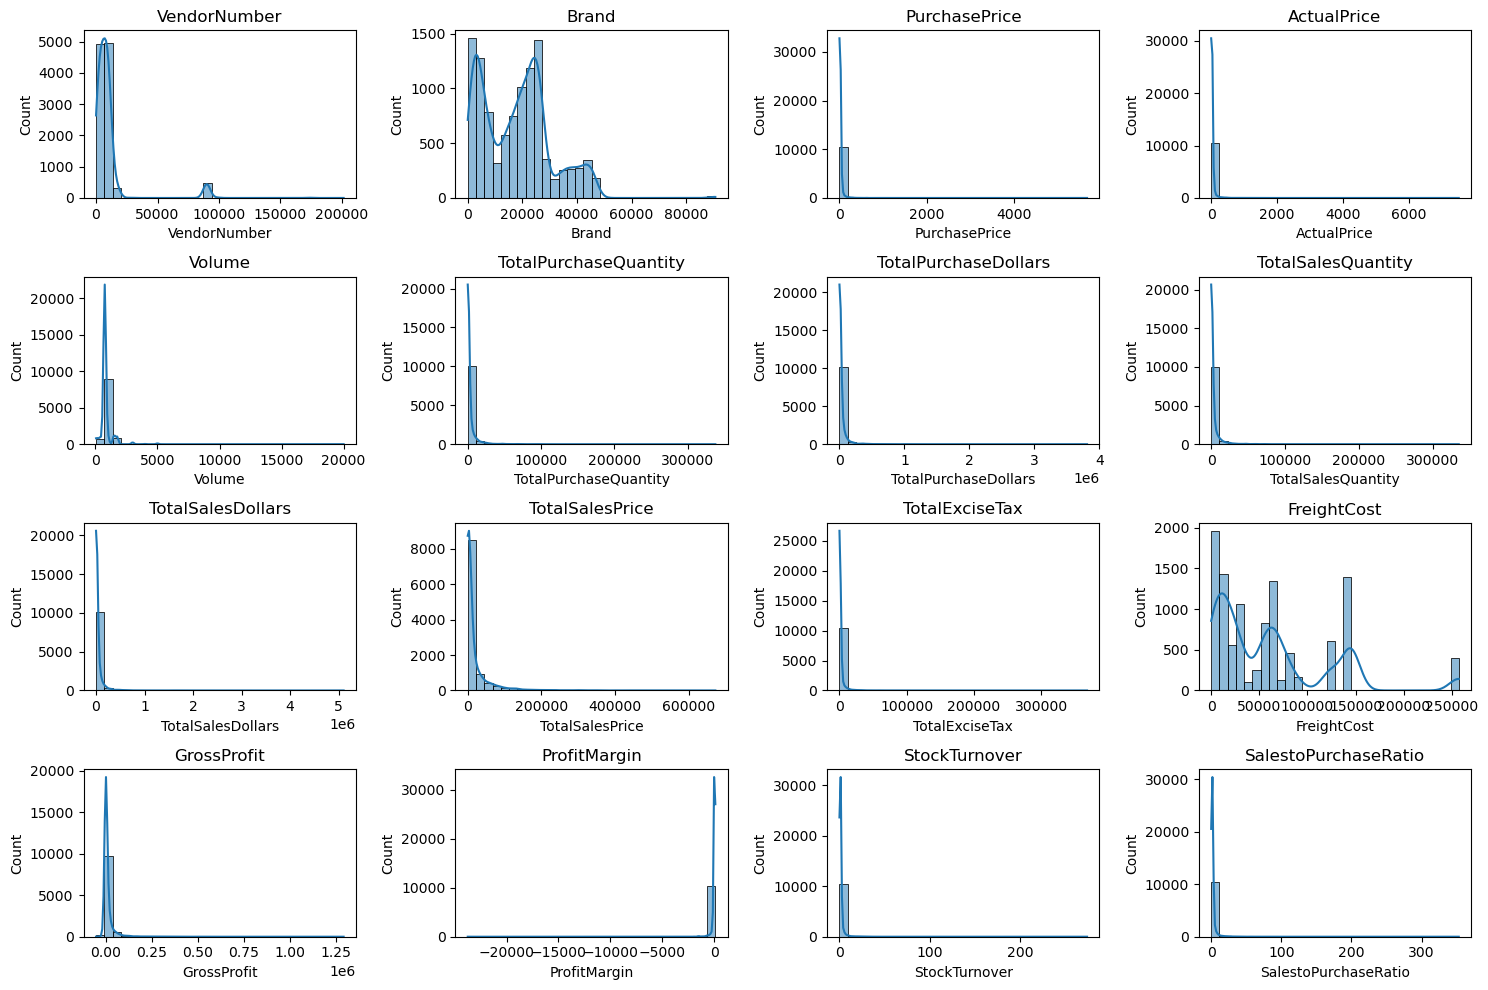

In [5]:
# Distribution Plots for Numerical Columns
numerical_cols =df.select_dtypes(include =np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

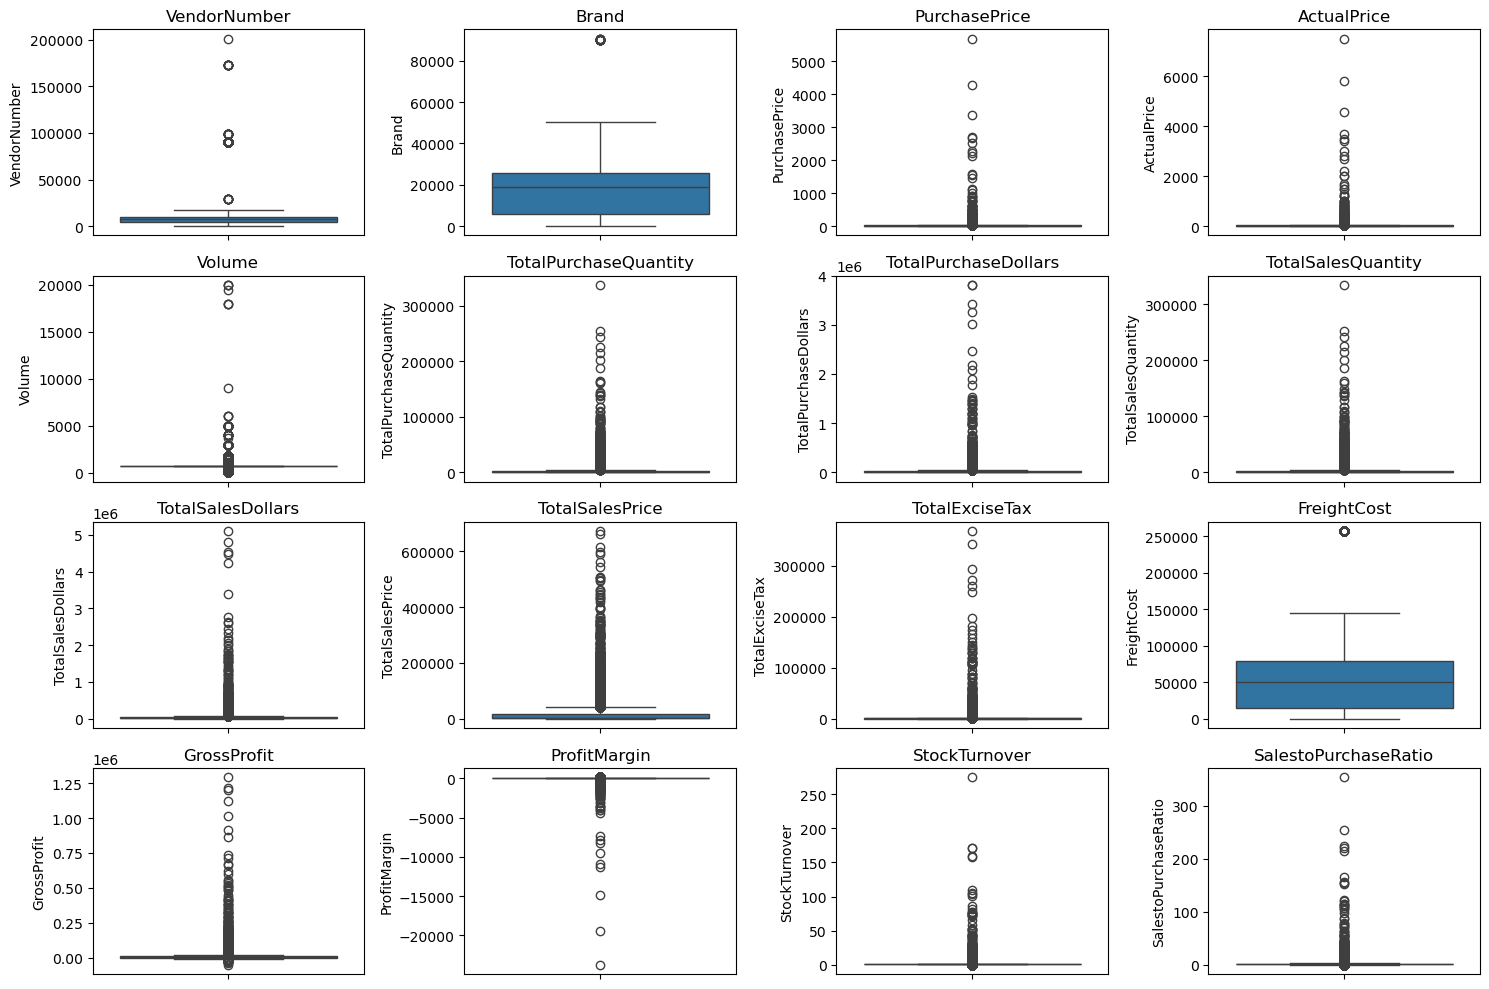

In [6]:
#outliers detection with Boxplot
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [7]:
# Filtering the data by removing inconsistencies
df= pd.read_sql('''
 select * from  vendor_sales_summary
 where GrossProfit > 0
 and ProfitMargin >0
 and TotalSalesQuantity >0
 ''',conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


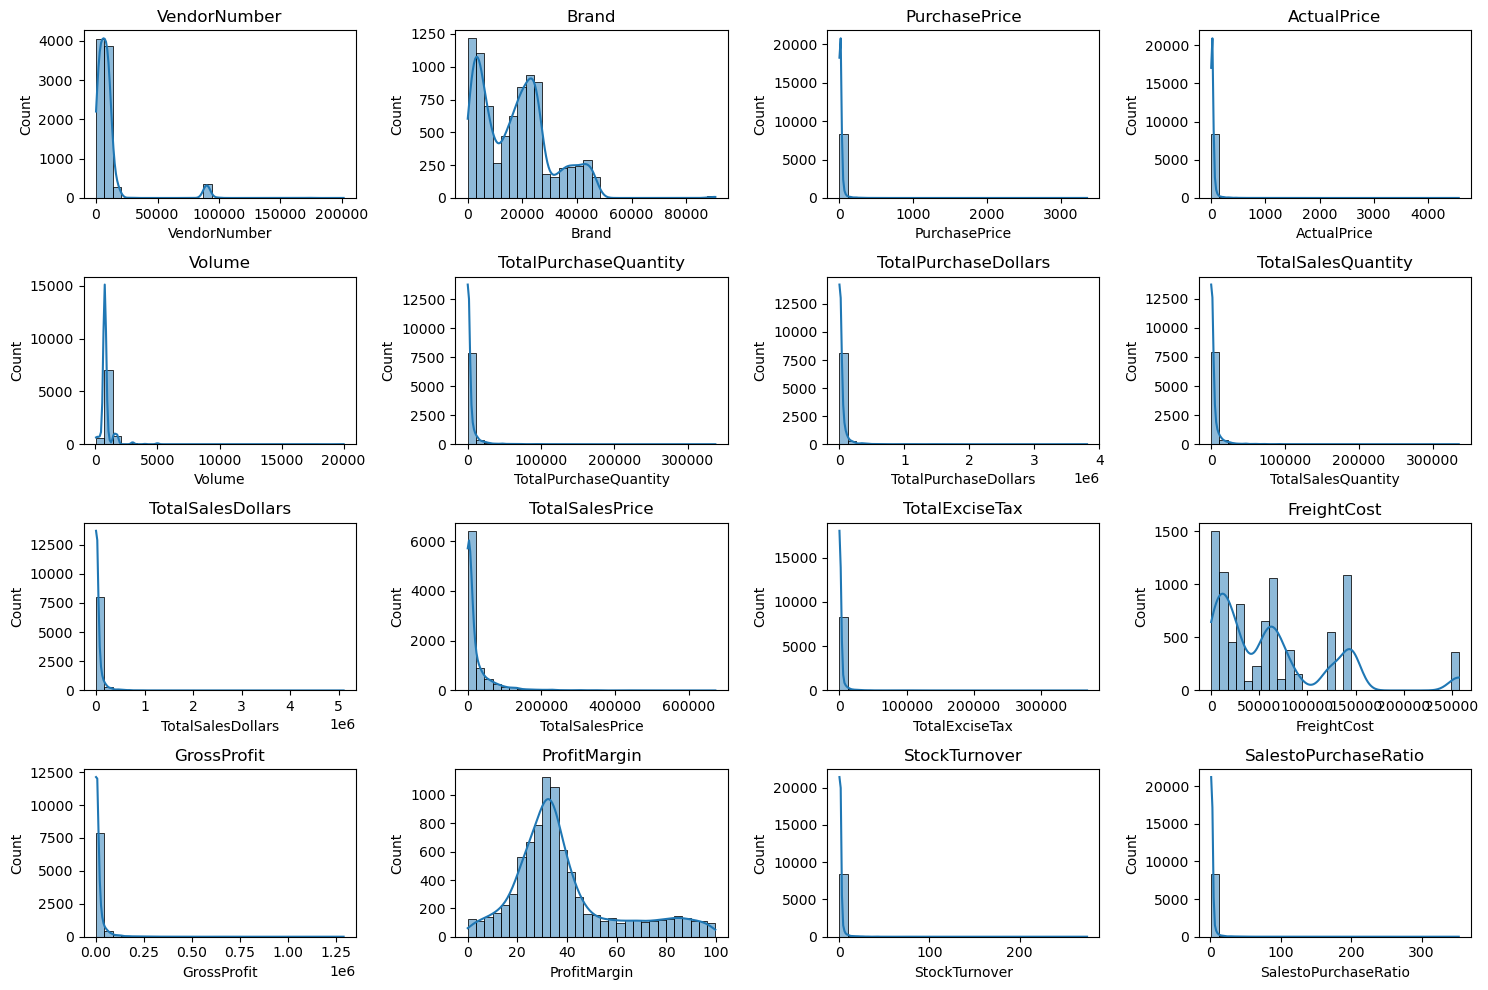

In [9]:
# Distribution Plots for Numerical Columns
numerical_cols =df.select_dtypes(include =np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

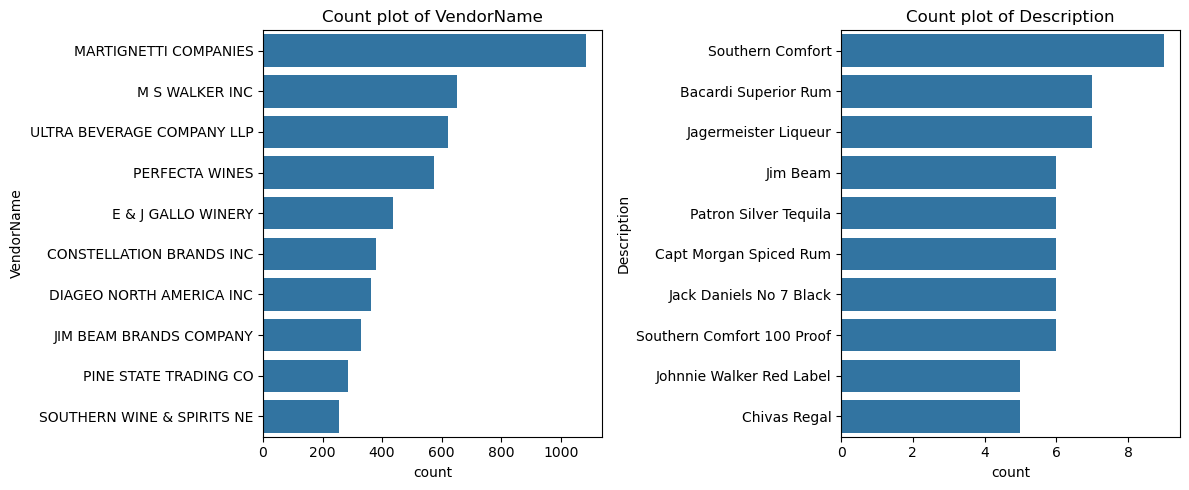

In [10]:
#CountPlot for categorical columns
categorical_cols =df.select_dtypes(include=['object']).columns

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # top10 categories
    plt.title('Count plot of '+col)
plt.tight_layout()
plt.show()


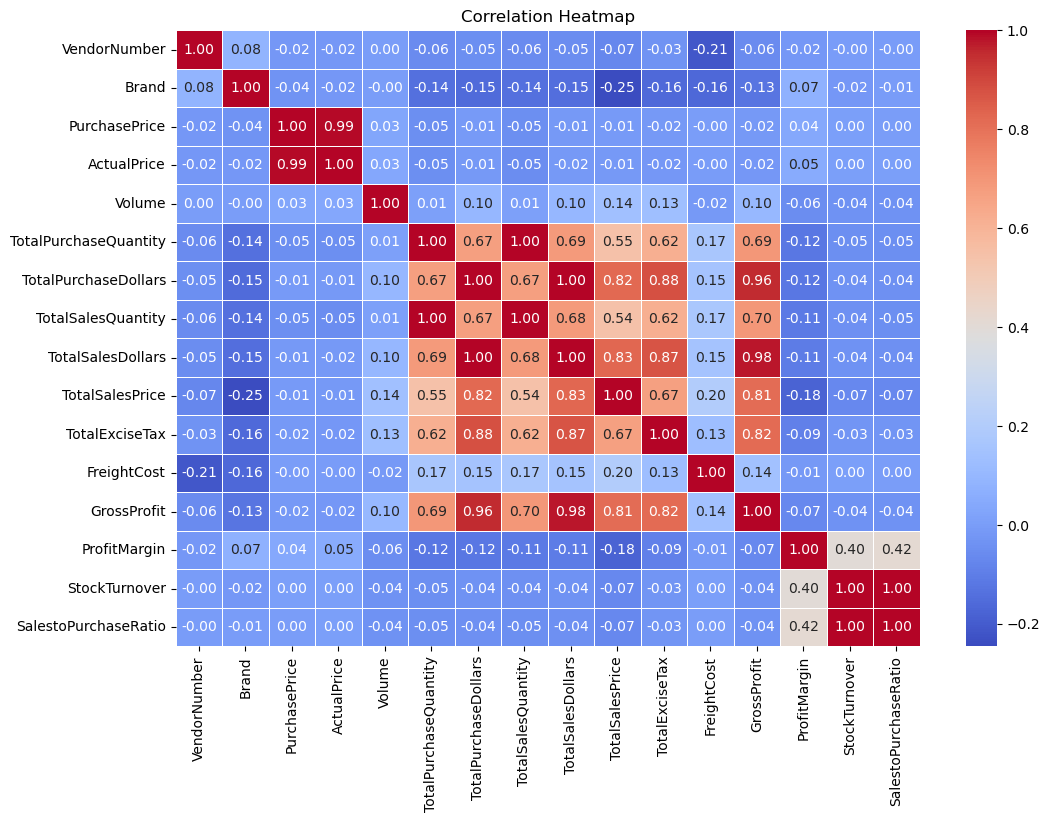

In [11]:
 #Correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix =df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Data Analysis

Q1 -identify Brands that need promotional or Pricing adjustments which exhibit lower sales performance but higher profit margins

In [12]:
brand_performance=df.groupby('Description').agg({
           'TotalSalesDollars' : 'sum',
            'ProfitMargin':'mean'
}
).reset_index()

In [13]:
low_sales_threshold =brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold =brand_performance['ProfitMargin'].quantile(0.85)

In [14]:
low_sales_threshold

np.float64(560.299)

In [15]:
high_margin_threshold

np.float64(64.97017552750113)

In [16]:
 #filters brands with low sales but high Profit margins
target_brands= brand_performance[
(brand_performance['TotalSalesDollars']<=low_sales_threshold) &
(brand_performance['ProfitMargin']>=high_margin_threshold)
]
print("Brands with low sales but high profit margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [17]:
brand_performance =brand_performance[brand_performance['TotalSalesDollars']<10000] #for better Visualization

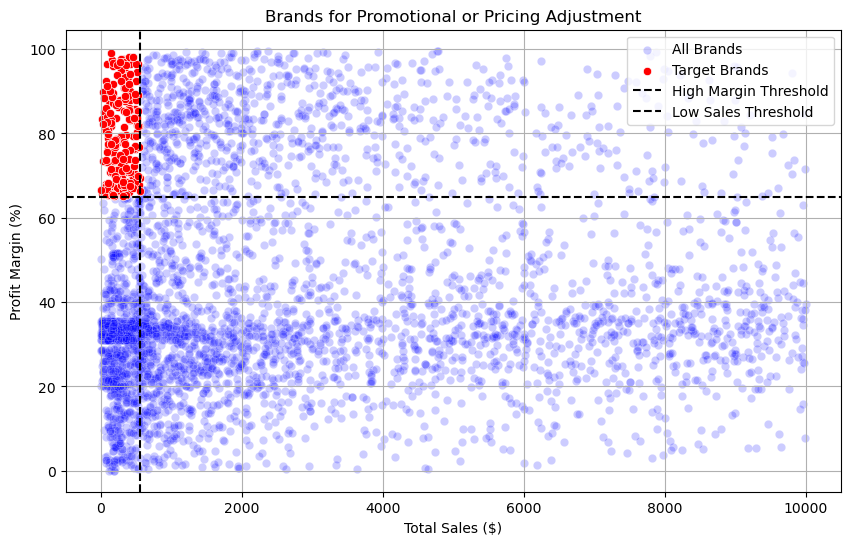

In [18]:
#Scatter plot for Brand_performance
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All Brands',alpha=0.2)
sns.scatterplot(data=target_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target Brands')
plt.axhline(high_margin_threshold ,linestyle='--',color='black',label='High Margin Threshold')
plt.axvline(low_sales_threshold ,linestyle='--',color='black',label='Low Sales Threshold')

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustment")
plt.legend()
plt.grid(True)
plt.show()


Which vendors and brands demonstrate the highest sales peroformance

In [19]:
def format_dollars(value):
    if value >=1_000_000:
        return f"{value/1_000_000:.2f}M   "
    elif value >1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [20]:
#Top Vendors & Brands Performance
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors.apply(lambda x :format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M   
MARTIGNETTI COMPANIES         39.33M   
PERNOD RICARD USA             32.06M   
JIM BEAM BRANDS COMPANY       31.42M   
BACARDI USA INC               24.85M   
CONSTELLATION BRANDS INC      24.22M   
E & J GALLO WINERY            18.40M   
BROWN-FORMAN CORP             18.25M   
ULTRA BEVERAGE COMPANY LLP    16.50M   
M S WALKER INC                14.71M   
Name: TotalSalesDollars, dtype: object

In [21]:
top_brands.apply(lambda x :format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M   
Tito's Handmade Vodka      7.40M   
Grey Goose Vodka           7.21M   
Capt Morgan Spiced Rum     6.36M   
Absolut 80 Proof           6.24M   
Jameson Irish Whiskey      5.72M   
Ketel One Vodka            5.07M   
Baileys Irish Cream        4.15M   
Kahlua                     3.60M   
Tanqueray                  3.46M   
Name: TotalSalesDollars, dtype: object

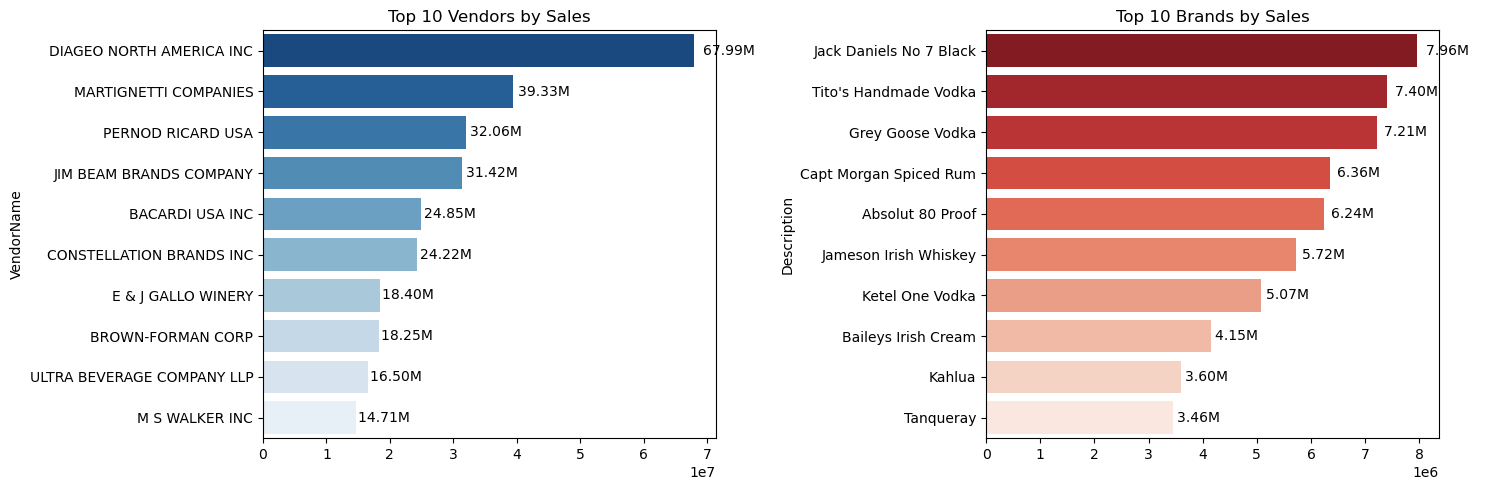

In [22]:
plt.figure(figsize=(15,5))
#Bar Plot for Top Vendors 
plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendors.index,x=top_vendors.values,palette='Blues_r')
plt.title('Top 10 Vendors by Sales')

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width()*0.02),
    bar.get_y() +bar.get_height()/2,
    format_dollars(bar.get_width()),
    ha='left',va='center', fontsize=10,color='black')
    
#Bar Plot for Brands 
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index.astype(str),x=top_brands.values,palette='Reds_r')
plt.title('Top 10 Brands by Sales')

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width()*0.02),
    bar.get_y() +bar.get_height()/2,
    format_dollars(bar.get_width()),
    ha='left',va='center', fontsize=10,color='black')
plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dollars?

In [23]:
vendor_performance =df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [24]:
vendor_performance['PurchaseContributions'] = (vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum())*100

In [25]:
vendor_performance =round(vendor_performance.sort_values('PurchaseContributions',ascending=False),2)

In [26]:
#Display Top 10 vendors
top_vendors =vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['CumulativeContributions'] =top_vendors['PurchaseContributions'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributions,CumulativeContributions
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


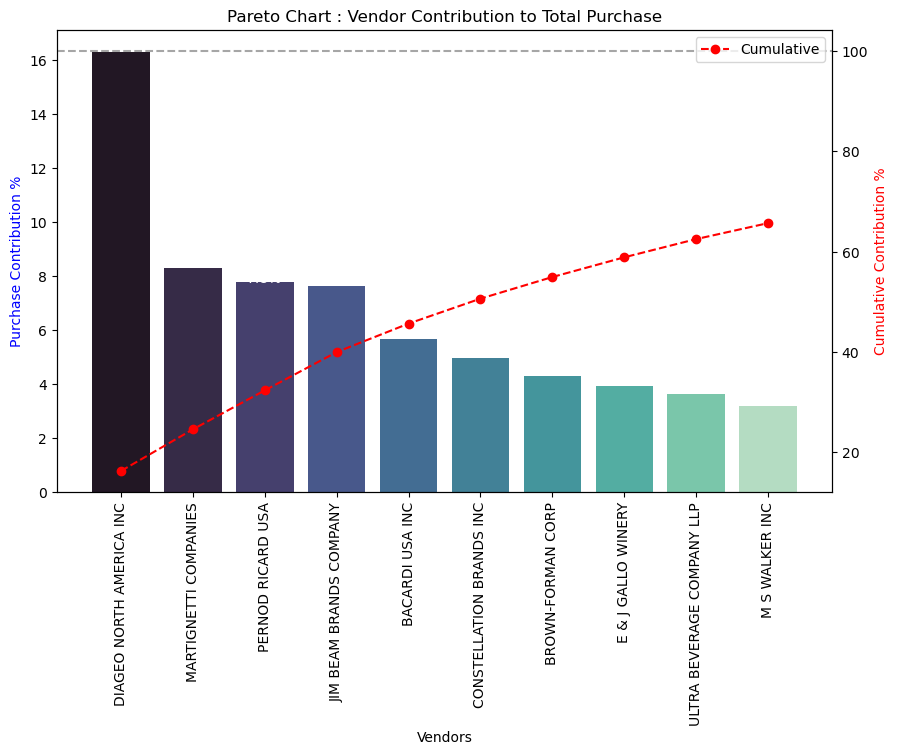

In [27]:
fig,ax1=plt.subplots(figsize=(10,6))

#Barplot for Purchase Contributions
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContributions'],palette='mako',ax=ax1)

for i,value in enumerate(top_vendors['PurchaseContributions']):
    ax1.text(i,value ,str(round(value, 1)) + "%" ,ha='center' ,fontsize=10,color='white')

#lineplot for cumulative Contributions
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'] ,top_vendors['CumulativeContributions'],color='red',marker='o',linestyle='dashed',label='Cumulative')

ax1.tick_params(axis='x', labelrotation=90)
ax1.set_ylabel('Purchase Contribution %' ,color='blue')
ax2.set_ylabel('Cumulative Contribution %' ,color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchase')

ax2.axhline(y=100,color='grey',linestyle='dashed',alpha=0.7)
ax2.legend(loc='upper right')

plt.show()


How much of total Procurment is dependent on the top vendors?

In [28]:
print(f" Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContributions'].sum(),2)} %")

 Total Purchase Contribution of top 10 vendors is 65.69 %


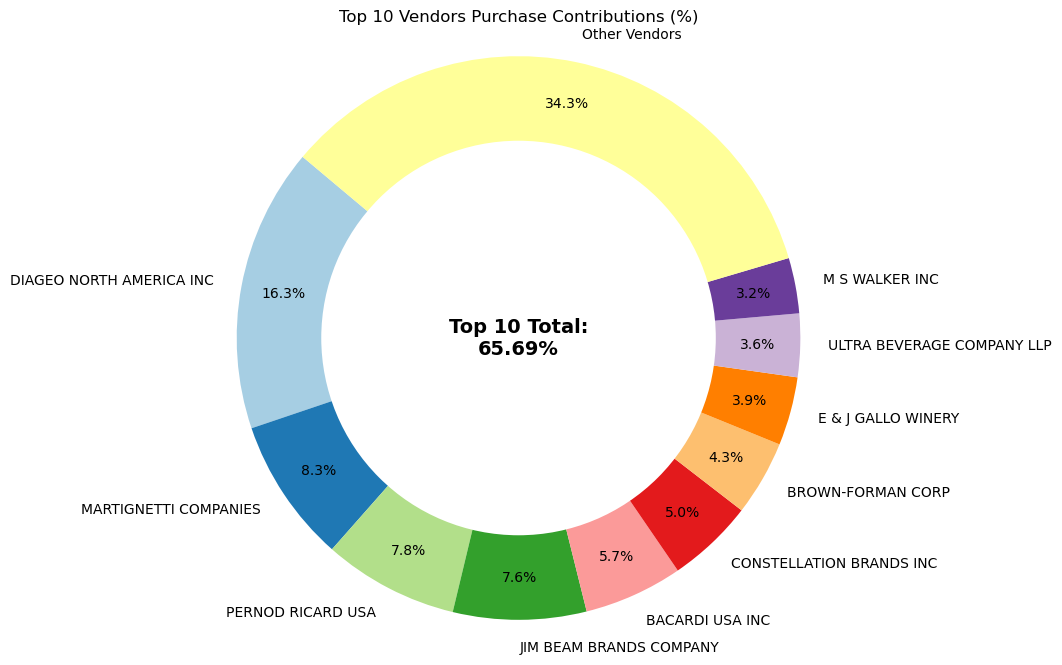

In [29]:
vendors =list(top_vendors['VendorName'].values)
purchase_contribution =list(top_vendors['PurchaseContributions'].values)
totalContributions =sum(purchase_contribution)
remainingContributions=100-totalContributions

#Append "Other Vendors category"
vendors.append('Other Vendors')
purchase_contribution.append(remainingContributions)

#Donut Chart
fig,ax =plt.subplots(figsize=(8,8))
wedges,texts,autotexts =ax.pie(purchase_contribution ,labels=vendors ,autopct ='%1.1f%%',
                              startangle =140 ,pctdistance =0.85 ,colors=plt.cm.Paired.colors)

#Draw a white circle in the centre to create a "donut" effect
center_circle =plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(center_circle)

#Add Total Contribution annotation in the centre
plt.text(0,0,f'Top 10 Total:\n{totalContributions:.2f}%',fontsize=14,fontweight='bold',ha='center',va='center')

plt.title('Top 10 Vendors Purchase Contributions (%)')

ax.axis('equal')
plt.show()

Does Purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost savings

In [30]:
df['UnitPurchasePrice'] =df['TotalPurchaseDollars'] /df['TotalPurchaseQuantity']
df['OrderSize'] =pd.qcut(df['TotalPurchaseQuantity'] ,q=3,labels=['Small' ,'Medium','Large'])
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,Small
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,Small


In [31]:
unit_price_persize =df.groupby('OrderSize')[['UnitPurchasePrice']].mean().reset_index()

In [32]:
unit_price_persize 

,OrderSize,UnitPurchasePrice
0,Small,39.068186
1,Medium,15.486414
2,Large,10.777625


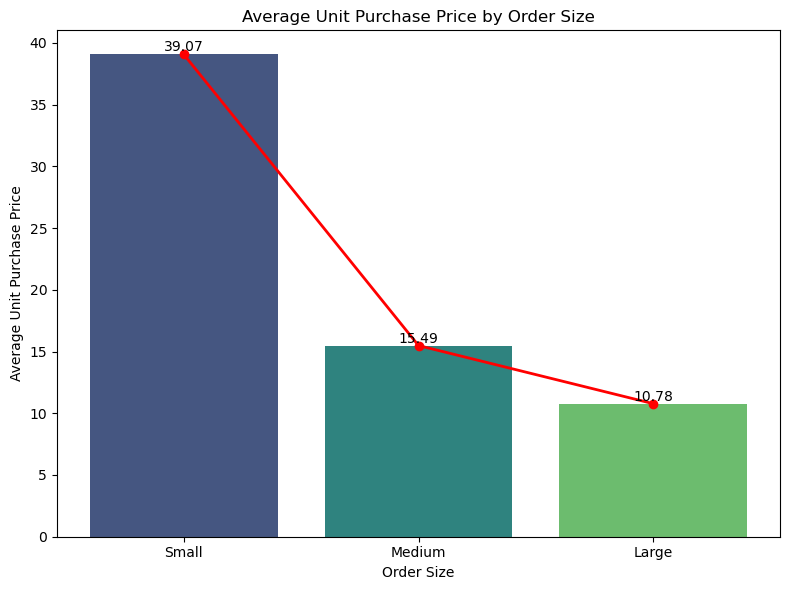

In [33]:
# plt.figure(figsize=(8,6))
fig,ax =plt.subplots(figsize=(8,6))
ax = sns.barplot(
    data=unit_price_persize,
    x='OrderSize',
    y='UnitPurchasePrice',
    palette='viridis'
)

# Draw line connecting bar heights
plt.plot(
    unit_price_persize['OrderSize'],
    unit_price_persize['UnitPurchasePrice'],
    color='red',
    marker='o',
    linewidth=2
)

for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Average Unit Purchase Price by Order Size')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')

plt.tight_layout()
plt.show()

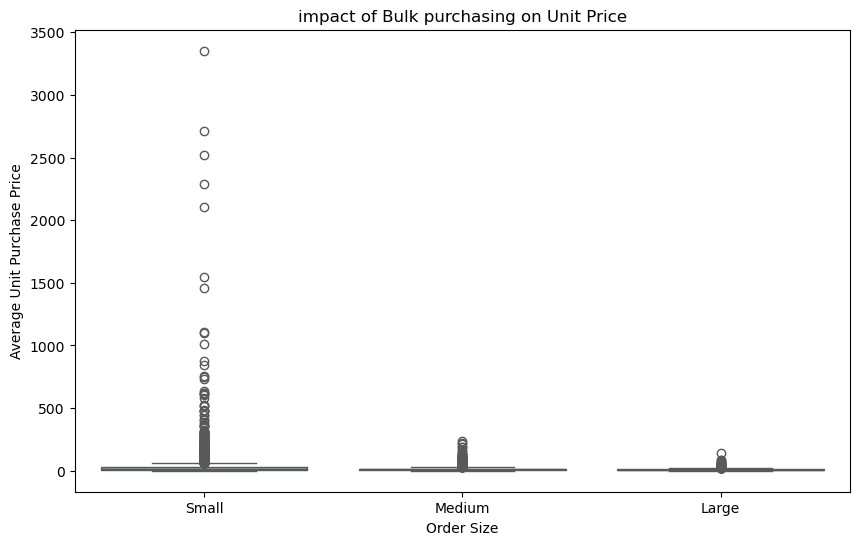

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df ,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title('impact of Bulk purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

Which vendors have low inventory turnover ,indicating excess stock and slow-moving products?

In [35]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover' ,ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


How much Capital is locked in unsold inventory per vendor ,and which vendors contribute the most of it

In [36]:
 df['UnsoldInventory'] =(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print(f"Total Unsold Capital : {format_dollars(df['UnsoldInventory'].sum())}")

Total Unsold Capital : 2.71M   


In [37]:
#Aggregate Capital Locked per Vendor
inventory_value_per_vendor =df.groupby('VendorName')[['UnsoldInventory']].sum().reset_index()

#Sort Vendors with the highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values('UnsoldInventory',ascending=False)
inventory_value_per_vendor['UnsoldInventory'] =inventory_value_per_vendor['UnsoldInventory'] .apply(format_dollars)
inventory_value_per_vendor.head(10) 

,VendorName,UnsoldInventory
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors

In [38]:
top_threshold =df['TotalSalesDollars'].quantile(0.75)
low_threshold =df['TotalSalesDollars'].quantile(0.25)

In [39]:
top_vendors= df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors= df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [40]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [41]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [42]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data)) #Standard error
    t_critical= stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical * std_err
    return mean_val,mean_val-margin_of_error,mean_val + margin_of_error
    

Top Vendors 95% CI:(30.74,31.61),Mean :31.18
Low Vendors 95% CI:(40.50,42.64),Mean :41.57


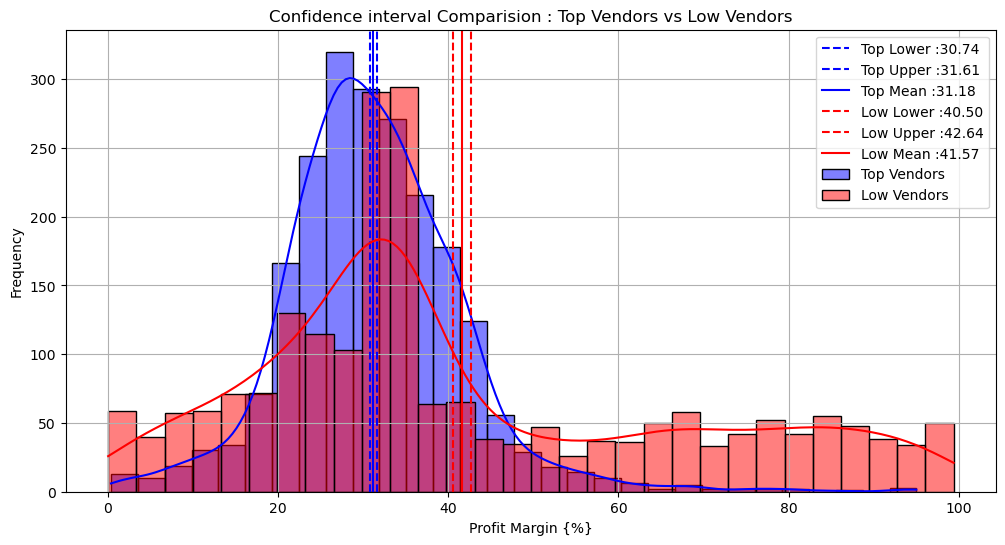

In [43]:
top_mean,top_lower,top_upper =confidence_interval(top_vendors)
low_mean,low_lower,low_upper =confidence_interval(low_vendors)

print(f"Top Vendors 95% CI:({top_lower:.2f},{top_upper:.2f}),Mean :{top_mean:.2f}")
print(f"Low Vendors 95% CI:({low_lower:.2f},{low_upper:.2f}),Mean :{low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top Vendors Plot
sns.histplot(top_vendors ,kde=True,color='blue',bins=30,alpha=0.5,label='Top Vendors')
plt.axvline(top_lower,color='blue',linestyle='--',label=f"Top Lower :{top_lower:.2f}")
plt.axvline(top_upper,color='blue',linestyle='--',label=f"Top Upper :{top_upper:.2f}")
plt.axvline(top_mean,color='blue',linestyle='-',label=f"Top Mean :{top_mean:.2f}")

#Low Vendors Plot
sns.histplot(low_vendors ,kde=True,color='red',bins=30,alpha=0.5,label='Low Vendors')
plt.axvline(low_lower,color='red',linestyle='--',label=f"Low Lower :{low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle='--',label=f"Low Upper :{low_upper:.2f}")
plt.axvline(low_mean,color='red',linestyle='-',label=f"Low Mean :{low_mean:.2f}")

#Finalize plot
plt.title('Confidence interval Comparision : Top Vendors vs Low Vendors')
plt.xlabel('Profit Margin {%}')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

Is there a significant difference in profit margins between top-performing and low-performing vendors?

In [46]:
top_threshold =df['TotalSalesDollars'].quantile(0.75)
low_threshold =df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

#performs two-sample t-test
t_stat,p_value =ttest_ind(top_vendors,low_vendors,equal_var=False)

#print results
print(f"T-Statistics:{t_stat:.4f},p-value:{p_value:.4f}")
if p_value <0.05:
    print('Reject ho: There is a significant diffrence in profit margins between top and low-performing vendors')
else:
    print('Fail to reject ho: No significant difference in profit margins')

T-Statistics:-17.6695,p-value:0.0000
Reject ho: There is a significant diffrence in profit margins between top and low-performing vendors
